In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from mamba_model import Mamba, MambaConfig
import mamba_model
import argparse
from DataProcessing import HankelMatrices, HankelMatricesSequences, Sequence2Sequence, Sequence2SequenceStates, Sequence2SequenceFuture, Sequence2SequencePast
import scipy.io
from torch.utils.data import DataLoader, TensorDataset


In [13]:
np.array([0, 1, 0, 0, 0]).shape

(5,)

In [ ]:
# Define constant pieces
ref1 = np.tile([0], (100, 1))
ref2 = np.tile([1], (100, 1))
ref3 = np.tile([0], (100, 1))
ref4 = np.tile([0], (100, 1))
ref5 = np.tile([0], (100, 1))

# Concatenate them along the first axis (time steps)
xref_traj = np.concatenate((ref1, ref2, ref3,ref4), axis=0)  # Shape (100, 2)

xref_traj.shape

(2000, 4)

In [2]:
device = 'cpu'
X_test = np.load("X_val.npy")
Y_test = np.load("Y_val.npy")

X_test = torch.FloatTensor(X_test[:500,:,:]).to(device)
Y_test = torch.FloatTensor(Y_test[:500,:,:]).to(device)

print("u_train shape:"+str(X_test.shape))
print("y_train shape:"+str(Y_test.shape))



u_train shape:torch.Size([500, 40, 6])
y_train shape:torch.Size([500, 40, 5])


In [20]:
class NetSequences(nn.Module):
    def __init__(self,in_dim,out_dim):
        super().__init__()
        D_model  = 96
        self.config = MambaConfig(d_model=D_model, n_layers=1, expand_factor = 1  , d_conv = 16, d_state = 16)
        self.lin1 = nn.Linear(in_dim,D_model)
        self.mamba = Mamba(self.config)
        self.MLP = nn.Linear(D_model,out_dim)
        

    def forward(self,x):
        # print("Input Shape:"+str(x.shape))
        x = self.lin1(x)
        x = self.mamba(x)
        x = self.MLP(x)
        return x.squeeze(0) 

In [21]:
model = NetSequences(6, 5)
model.load_state_dict(torch.load("State_dicts/ZOH_D96_dstate16_Conv16_N40", map_location=torch.device('cpu'))['model_state_dict'])
model = model.to(device)

In [22]:
model.eval()
mat = model(X_test)
yhat = mat.detach().cpu().numpy()

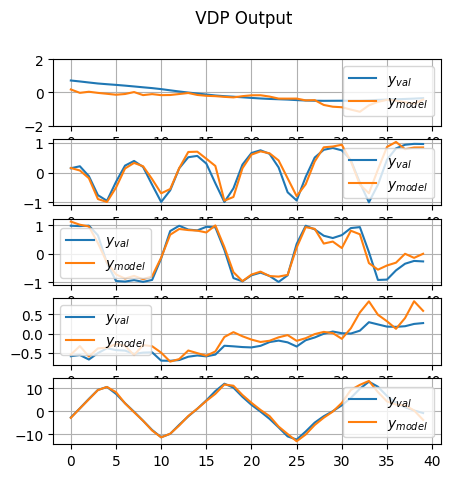

In [23]:
MAE = np.mean(np.abs(yhat - Y_test.numpy()),1)
RMAE = np.sqrt(MAE)
NRMAE = RMAE/(np.max(Y_test.numpy())-np.min(Y_test.numpy()))

N_step  = 0
Index  = 20

fig, axs = plt.subplots(5,figsize=(5, 5),)
fig.suptitle(" VDP Output")
axs[0].plot(Y_test[Index,: ,0], label="$y_{val}$")
axs[0].plot(yhat[Index,: ,0], label = "$y_{model}$")
axs[0].legend()
axs[0].grid()
axs[0].set_ylim(-2, 2)

axs[1].plot(Y_test[Index,: ,1], label="$y_{val}$")
axs[1].plot(yhat[Index,: ,1], label = "$y_{model}$")
axs[1].legend()
axs[1].grid()


axs[2].plot(Y_test[Index,:,2], label="$y_{val}$")
axs[2].plot(yhat[Index,:,2], label = "$y_{model}$")
axs[2].legend()
axs[2].grid()

axs[3].plot(Y_test[Index,: ,3], label="$y_{val}$")
axs[3].plot(yhat[Index,: ,3], label = "$y_{model}$")
axs[3].legend()
axs[3].grid()

axs[4].plot(Y_test[Index,: ,4], label="$y_{val}$")
axs[4].plot(yhat[Index,:,4], label = "$y_{model}$")
axs[4].legend()
axs[4].grid()



fig.savefig("MambaValidationSetSNR20.png", format='png')

In [24]:
TotalError = np.sum(MAE)
print("Total Error:"+str(TotalError))

Total Error:402.37405


In [25]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# Calculate R-squared
r2_x1 = r2_score(Y_test[:,:,0].numpy(), yhat[:,:,0] )
r2_x2 = r2_score(Y_test[:,:,1].numpy(), yhat[:,:,1] )
r2_x3 = r2_score(Y_test[:,:,2].numpy(), yhat[:,:,2] )
r2_x4 = r2_score(Y_test[:,:,3].numpy(), yhat[:,:,3] )
r2_x5 = r2_score(Y_test[:,:,4].numpy(), yhat[:,:,4] )

print(f"R-squared on validation set: {r2_x1}")
print(f"R-squared on validation set: {r2_x2}")
print(f"R-squared on validation set: {r2_x3}")
print(f"R-squared on validation set: {r2_x4}")
print(f"R-squared on validation set: {r2_x5}")



R-squared on validation set: 0.8427723050117493
R-squared on validation set: 0.9335207939147949
R-squared on validation set: 0.9372740983963013
R-squared on validation set: 0.8936439752578735
R-squared on validation set: 0.982667088508606


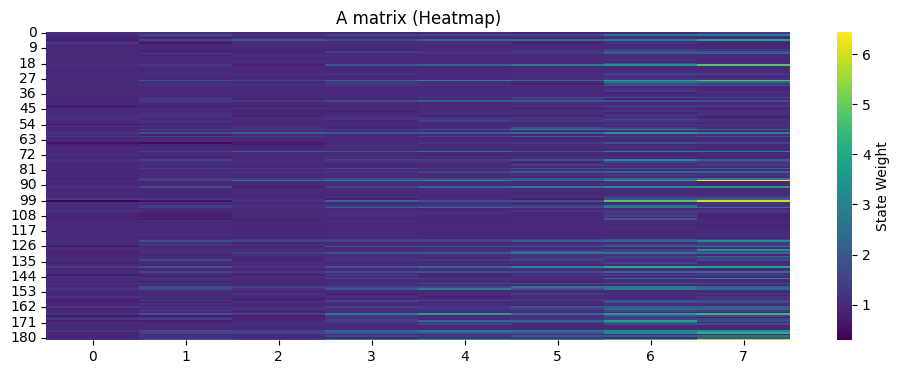

In [9]:
import seaborn as sns
# 2. Heatmap Style Attention Map

plt.figure(figsize=(12, 4))  # Shorter height for heatmap
sns.heatmap(torch.exp(model.mamba.layers[0].mixer.A_log).detach().numpy(),  # Reshape for heatmap
            cmap="viridis",  # Choose a suitable colormap
            xticklabels=True,  # Hide x-axis ticks if many time steps
            cbar_kws={'label': 'State Weight'}) # Add a colorbar with label


plt.title("A matrix (Heatmap)")
plt.show()

In [18]:
from scipy.io import savemat

#RMSBlock1
RMSWeight1 = model.mamba.layers[0].norm.weight.detach().numpy()

#RMSBlock2
RMSWeight2 = model.mamba.norm_f.weight.detach().numpy()

#Input Linear Projection to embedding
LinearInWeight = model.lin1.weight.detach().numpy()
LinearInBias = model.lin1.bias.detach().numpy()

#Expansion Linear Projection
LinearExpansionWeight  = model.mamba.layers[0].mixer.in_proj.weight.detach().numpy()
#No Bias

#Convolutional Layer
ConvWeight = model.mamba.layers[0].mixer.conv1d.weight.detach().numpy()
ConvBias = model.mamba.layers[0].mixer.conv1d.bias.detach().numpy()

#DeltaBC Projection
SelectionProjectionWeight = model.mamba.layers[0].mixer.x_proj.weight.detach().numpy()
#No Bias

#Sampling Time Projection
DeltaTProjectionWeight = model.mamba.layers[0].mixer.dt_proj.weight.detach().numpy()
DeltaTProjectionBias = model.mamba.layers[0].mixer.dt_proj.bias.detach().numpy()

##SSM Paramters
A = model.mamba.layers[0].mixer.A_log.detach().numpy()
D = model.mamba.layers[0].mixer.D.detach().numpy()


#Reduction Projection
LinearReductionWeight = model.mamba.layers[0].mixer.out_proj.weight.detach().numpy()
#No bias

# #Output Projection
LinearSequenceProjectionWeight = model.MLP.weight.detach().numpy()
LinearSequenceProjectionBias = model.MLP.bias.detach().numpy()


#Output Projection
LinearOutputWeight = model.MLP.weight.detach().numpy()
LinearOutputBias = model.MLP.bias.detach().numpy()





# savemat(
#     "MambaParameters"+".mat",
#     {'LinearInWeight': LinearInWeight, 'LinearInBias': LinearInBias ,  'LinearExpansionWeight': LinearExpansionWeight,
#       'ConvWeight': ConvWeight, 'ConvBias': ConvBias, 'SelectionProjectionWeight': SelectionProjectionWeight,
#         'DeltaTProjectionWeight': DeltaTProjectionWeight, 'DeltaTProjectionBias': DeltaTProjectionBias, 
#          'A': A, 'D': D, 'LinearReductionWeight': LinearReductionWeight,  'LinearOutputWeight': LinearOutputWeight, 'LinearOutputBias': LinearOutputBias,'RMSWeight1': RMSWeight1 ,'RMSWeight2': RMSWeight2})

# savemat(
#     "MambaParameters"+".mat",
#     {'LinearInWeight': LinearInWeight, 'LinearInBias': LinearInBias ,  'LinearExpansionWeight': LinearExpansionWeight,
#       'ConvWeight': ConvWeight, 'ConvBias': ConvBias, 'SelectionProjectionWeight': SelectionProjectionWeight,
#         'DeltaTProjectionWeight': DeltaTProjectionWeight, 'DeltaTProjectionBias': DeltaTProjectionBias, 
#          'A': A, 'D': D, 'LinearReductionWeight': LinearReductionWeight,'LinearSequenceProjectionWeight': LinearSequenceProjectionWeight,  'LinearSequenceProjectionBias': LinearSequenceProjectionBias,   'LinearReductionWeight':LinearReductionWeight ,  'LinearOutputWeight': LinearOutputWeight, 'LinearOutputBias': LinearOutputBias,'RMSWeight1': RMSWeight1 ,'RMSWeight2': RMSWeight2})


In [19]:
from numpy import linalg as LA

print("Conditioning number of lin1: "+ str(LA.cond(model.lin1.weight.detach().numpy())))
print("Conditioning number of MLP: "+ str(LA.cond(model.MLP.weight.detach().numpy())))
print("Conditioning number of A_log: "+ str(LA.cond(model.mamba.layers[0].mixer.A_log.detach().numpy())))
print("Conditioning number of A: "+ str(LA.cond(A)))
print("Conditioning number of SelectionProjectionWeight: "+ str(LA.cond(SelectionProjectionWeight)))
print("Conditioning number of DeltaTProjectionWeight: "+ str(LA.cond(DeltaTProjectionWeight)))
print("Conditioning number of dt_proj: "+ str(LA.cond(model.mamba.layers[0].mixer.dt_proj.weight.detach().numpy())))
print("Conditioning number of LinearInWeight: "+ str(LA.cond(LinearInWeight)))
print("Conditioning number of LinearExpansionWeight: "+ str(LA.cond(LinearExpansionWeight)))
print("Conditioning number of LinearReductionWeight: "+ str(LA.cond(LinearReductionWeight)))
print("Conditioning number of LinearOutputWeight: "+ str(LA.cond(LinearOutputWeight)))
print("Conditioning number of ConvWeight: "+ str(LA.cond(ConvWeight)))

Conditioning number of lin1: 8.651842
Conditioning number of MLP: 1.661939
Conditioning number of A_log: 34.8287
Conditioning number of A: 34.8287
Conditioning number of SelectionProjectionWeight: 9.791332
Conditioning number of DeltaTProjectionWeight: 2.0641346
Conditioning number of dt_proj: 2.0641346
Conditioning number of LinearInWeight: 8.651842
Conditioning number of LinearExpansionWeight: 2.7735213e+38
Conditioning number of LinearReductionWeight: 3.6202083e+17
Conditioning number of LinearOutputWeight: 1.661939
Conditioning number of ConvWeight: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1